# 🛠️ Krok 1: Przygotowanie narzędzi i środowiska
Na początek musimy pobrać nasz zestaw funkcji (`utils.py`) bezpośrednio z repozytorium na GitHubie. Dzięki temu będziemy mieli dostęp do wszystkich przygotowanych wcześniej narzędzi do wczytywania, czyszczenia i wizualizacji danych wewnątrz środowiska Google Colab.

In [1]:
# 1. Pobieranie pliku utils.py z GitHuba do środowiska Colab
import requests
import os

url = "https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/pipeline/utils.py"
r = requests.get(url)
with open('utils.py', 'w') as f:
    f.write(r.text)

# 2. Instalacja brakujących zależności (opcjonalnie, Colab większość ma)
!pip install seaborn matplotlib pandas numpy scipy

# 3. Import wszystkich funkcji z pobranego pliku
from utils import *
import pandas as pd

print("✅ Środowisko gotowe! Funkcje zostały zaimportowane.")

✅ Środowisko gotowe! Funkcje zostały zaimportowane.


# 📂 Krok 2: Wczytywanie zbiorów danych z GitHuba
Dane analityczne są przechowywane w folderze `data` naszego repozytorium. Twoim zadaniem jest wykorzystanie funkcji `wczytaj_dane`, aby zaimportować dwa kluczowe pliki: `world_data.csv` (dane demograficzne) oraz `happiness_index.csv` (wskaźniki szczęścia).

> **Wskazówka:** Wykorzystaj zdefiniowaną zmienną `BAZA_URL`, aby stworzyć pełną ścieżkę do plików.

In [2]:
# Bazowy adres RAW do danych
BAZA_URL = "https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/data/"

# Wczytaj dane demograficzne
df_world = wczytaj_dane(
    # TO DO: Podaj pełny link do pliku world_data.csv korzystając z BAZA_URL (Wskazówka BAZA_URL + "nazwa_pliku.csv")
)

# Wczytaj dane o szczęściu
df_happiness = wczytaj_dane(
    # TO DO: Podaj pełny link do pliku happiness_index.csv korzystając z BAZA_URL (Wskazówka BAZA_URL + "nazwa_pliku.csv")
)

display(df_world.head())

Wczytywanie danych z: https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/data/world_data.csv...
Wczytywanie i wstępne czyszczenie zakończone sukcesem.
Wczytywanie danych z: https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/data/happiness_index.csv...
Wczytywanie i wstępne czyszczenie zakończone sukcesem.


,country,region,population,coastline_coast/area_ratio,arable_perc,crops_perc,other_perc,climate,agriculture,industry,service,agricultural_land_perc,land_areakm2,forested_area_perc,latitude,longitude
0,Algeria,AFRICA,32930091,0.04,3.22,0.25,96.53,1.0,0.101,0.600,0.298,17.4,NaN,0.8,28.033886,1.659626
1,Angola,AFRICA,12127071,0.13,2.41,0.24,97.35,NaN,0.096,0.658,0.246,47.5,NaN,46.3,-11.202692,17.873887
2,Benin,AFRICA,7862944,0.11,18.08,2.40,79.52,2.0,0.316,0.138,0.546,33.3,112.622,37.8,9.307690,2.315834
3,Botswana,AFRICA,1639833,0.00,0.65,0.01,99.34,1.0,0.024,0.469,0.507,45.6,581.730,18.9,-22.328474,24.684866
4,Burkina Faso,AFRICA,13902972,0.00,14.43,0.19,85.38,2.0,0.322,0.196,0.482,44.2,274.200,19.3,12.238333,-1.561593


# 🧹 Krok 3: Czyszczenie i przygotowanie danych (Data Cleaning)
Surowe dane rzadko są gotowe do analizy. W tej sekcji wykonasz trzy kluczowe operacje:
1. **Łączenie:** Złożysz dwie osobne tabele w jedną wspólną bazę.
2. **Usuwanie braków:** Pozbędziesz się wierszy, które nie posiadają kluczowych informacji.
3. **Usuwanie outlierów:** Wyeliminujesz błędy statystyczne i wartości ekstremalne, które mogłyby zafałszować ostateczne trendy.

In [3]:
# 1. Połącz dane o świecie z danymi o szczęściu
df_merged = polacz_dane(
    # TO DO: Wskaż dwie ramki danych do połączenia oraz wspólny klucz (nazwa kraju)
)

# 2. Usuń brakujące wartości w kolumnie ze wskaźnikiem szczęścia
df_clean = usun_nan(
    # TO DO: Podaj ramkę df_merged oraz nazwę kolumny 'life_evaluation'
)

# 3. Usuń wartości odstające (outliery) dla wybranych parametrów
df_final = usun_outliery(
    # TO DO: Podaj ramkę df_clean oraz listę kolumn: 'gdp_per_capita' i 'population'
)

print(f"Dane przefiltrowane. Pozostało {len(df_final)} rekordów.")

Operacja łączenia danych zakończona pomyślnie.
Usunięto 177 wierszy zawierających wartości odstające.
Dane przefiltrowane. Pozostało 1386 czystych rekordów.


# 📈 Krok 4: Analiza korelacji i szukanie trendów
Zanim zaczniemy rysować wykresy, musimy sprawdzić matematycznie, które zjawiska są ze sobą powiązane. Wykorzystamy do tego **współczynnik korelacji Pearsona**.
* Wartości bliskie **1** oznaczają silną zależność dodatnią.
* Wartości bliskie **-1** oznaczają silną zależność ujemną.
* Parametr `prog_korelacji` pozwoli nam odsiać "szum" i skupić się tylko na istotnych związkach.

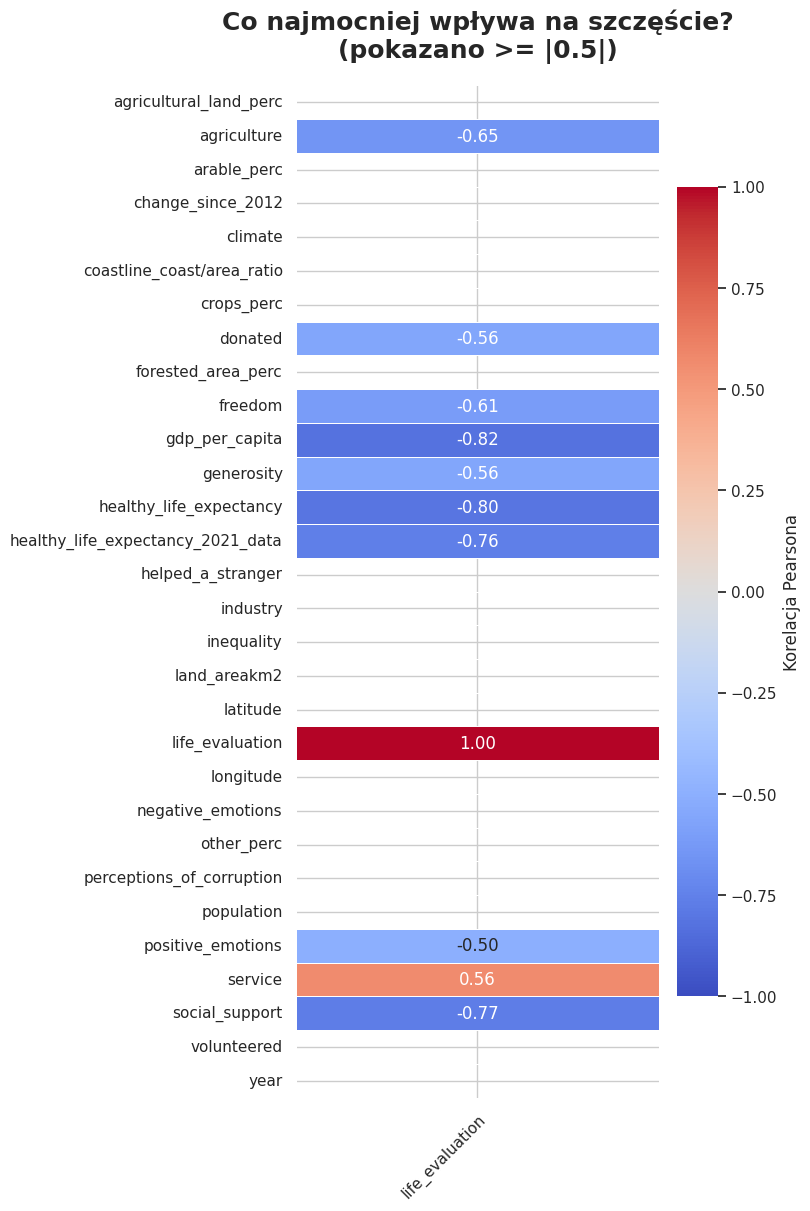

In [5]:
# Sprawdzamy, co najbardziej koreluje z oceną życia (szczęściem)
# Wygeneruj tabelę korelacji
tabela_korelacji(
    # TO DO: Podaj ramkę df_final oraz wskaż 'life_evaluation' jako kolumnę docelową.
    # Dodaj parametr prog_korelacji=0.5, aby ukryć słabe związki.
)

# 📊 Krok 5: Wielowymiarowa wizualizacja danych
Czas na finał analizy! Stworzymy **wykres bąbelkowy**. Pozwala on na jednym obrazie przedstawić aż 4 wymiary danych:
1. **Oś X:** Zamożność (PKB).
2. **Oś Y:** Poczucie szczęścia.
3. **Wielkość bąbelka:** Populacja kraju.
4. **Kolor bąbelka:** Region świata (kontynent).

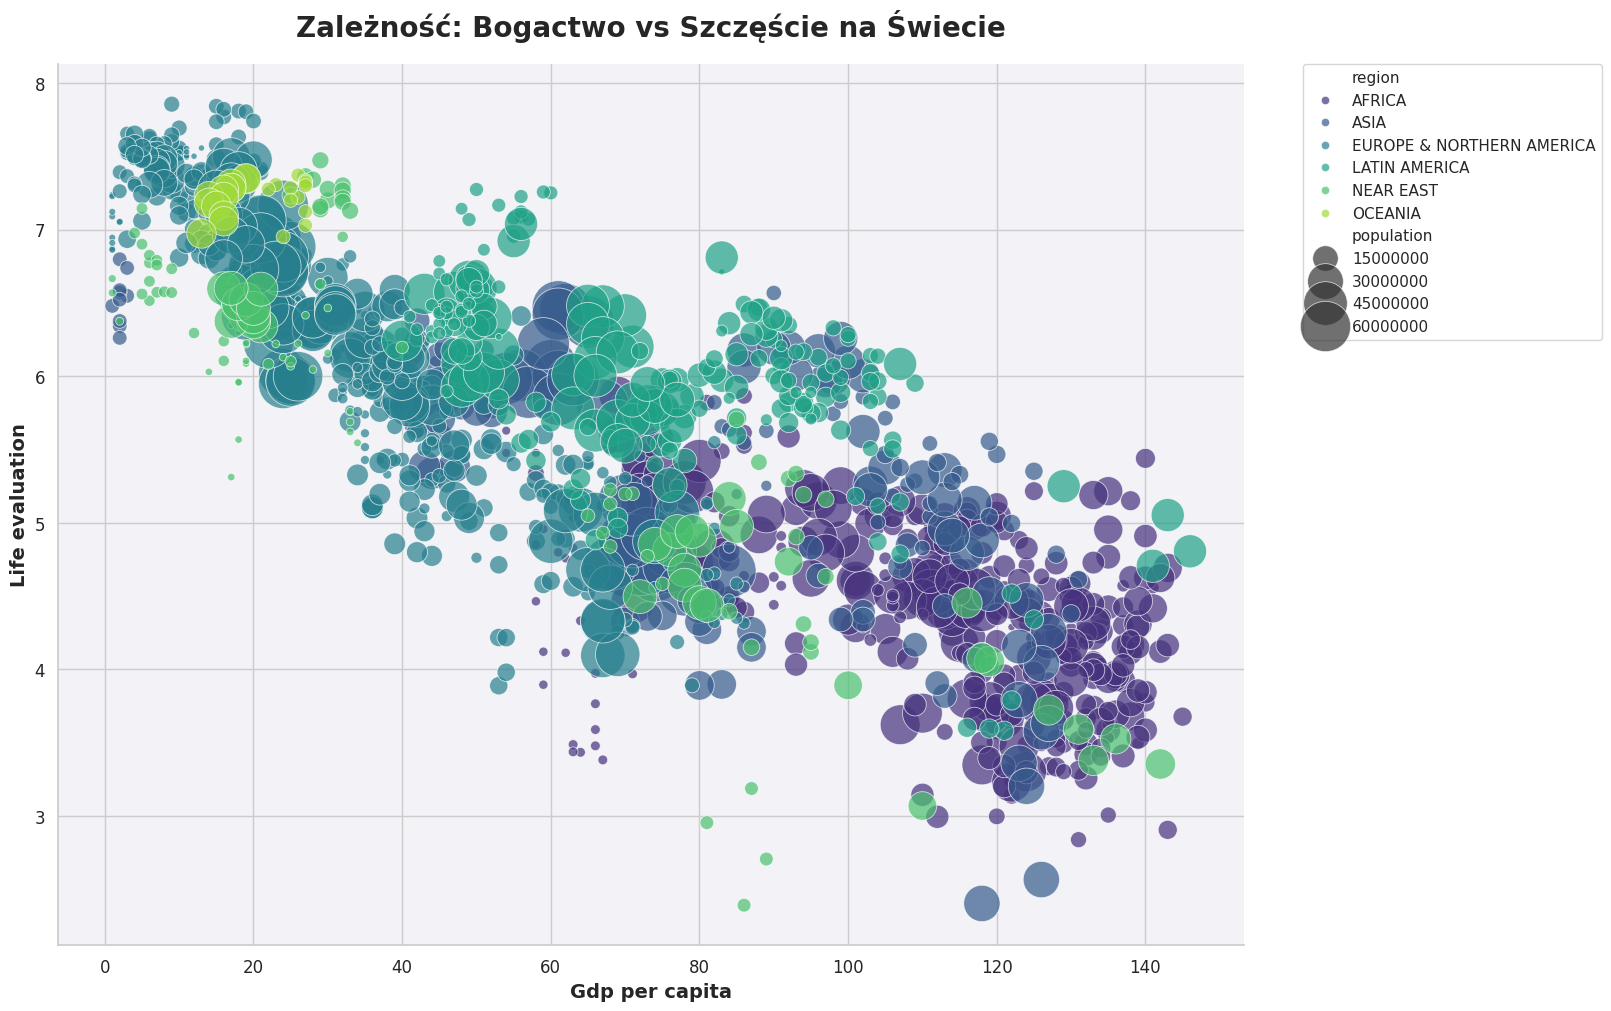

In [6]:
# Stwórz wykres bąbelkowy
wykres_babelkowy(
    # TO DO: Uzupełnij parametry:
    # dane=df_final,
    # osie X i Y (PKB i Szczęście),
    # rozmiar (populacja),
    # grupa (region/kontynent)
)